In [1]:
!pip install scanpy squidpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dask[array,dataframe] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a 

In [2]:
!pip install leidenalg igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 17.4 MB/s eta 0:00:00


In [3]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.ndimage import gaussian_filter

In [4]:
adata = sc.datasets.visium_sge(
    sample_id="V1_Mouse_Brain_Sagittal_Posterior"
)
#V1_Adult_Mouse_Brain
#V1_Adult_Mouse_Brain_Coronal_Section_1
#V1_Adult_Mouse_Brain_Coronal_Section_2
#V1_Mouse_Brain_Sagittal_Anterior
#V1_Mouse_Brain_Sagittal_Posterior
#V1_Mouse_Brain_Sagittal_Posterior_Section_2
#V1_Mouse_Brain_Sagittal_Anterior_Section_2

/tmp/ipykernel_7277/717152748.py:1: FutureWarning: Use `squidpy.datasets.visium` instead.
  adata = sc.datasets.visium_sge(


  0%|          | 0.00/9.26M [00:00<?, ?B/s]

  0%|          | 0.00/20.1M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
adata

AnnData object with n_obs × n_vars = 3355 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [6]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [7]:
sc.pp.pca(adata)

sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
)

In [8]:
adata.obs.head()
adata.obs.columns
adata.obs.iloc[0]

,AAACAAGTATCTCCCA-1
in_tissue,1.000000
array_row,50.000000
array_col,102.000000
n_genes_by_counts,3089.000000
log1p_n_genes_by_counts,8.035926
total_counts,9195.000000
log1p_total_counts,9.126524
pct_counts_in_top_50_genes,37.009244
pct_counts_in_top_100_genes,43.534530
pct_counts_in_top_200_genes,51.636759


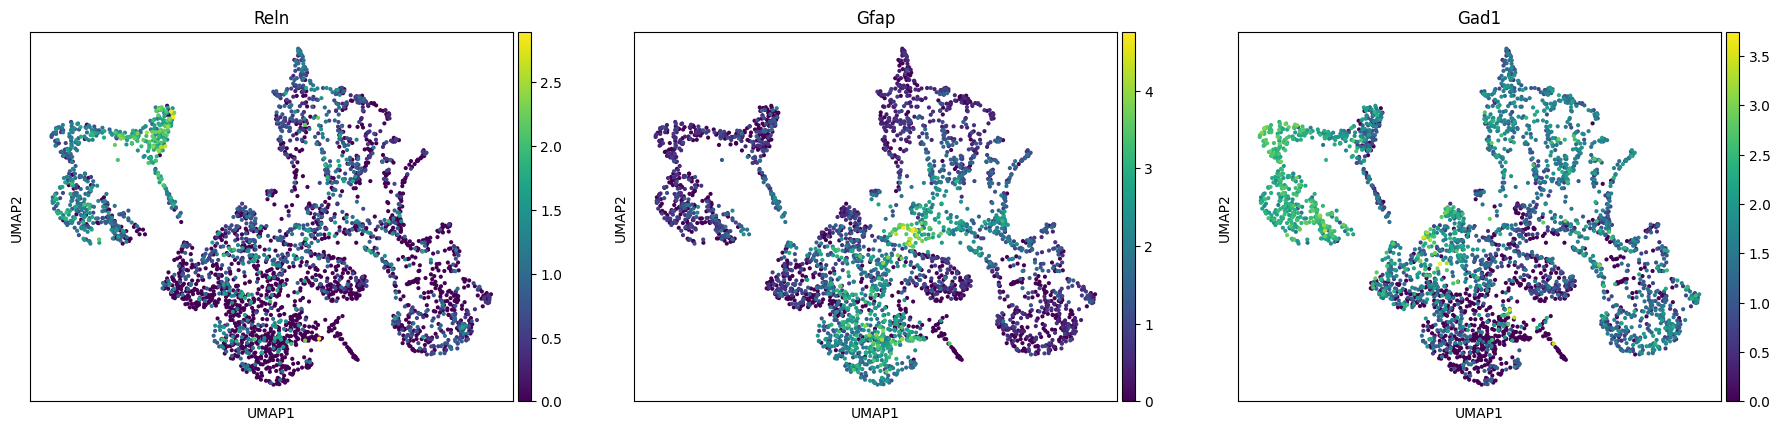

In [9]:
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["Reln", "Gfap", "Gad1"]
)

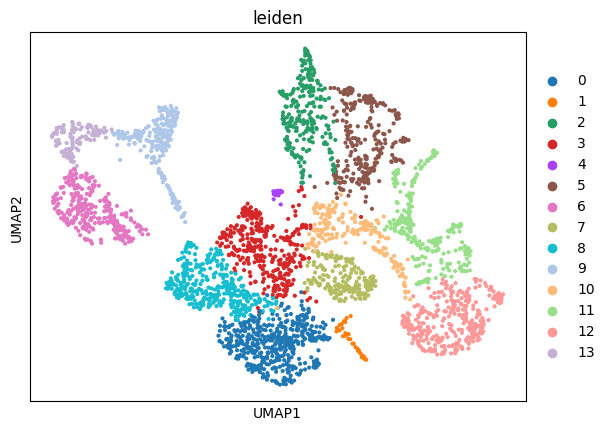

In [10]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

sc.pl.umap(
    adata,
    color="leiden"
)

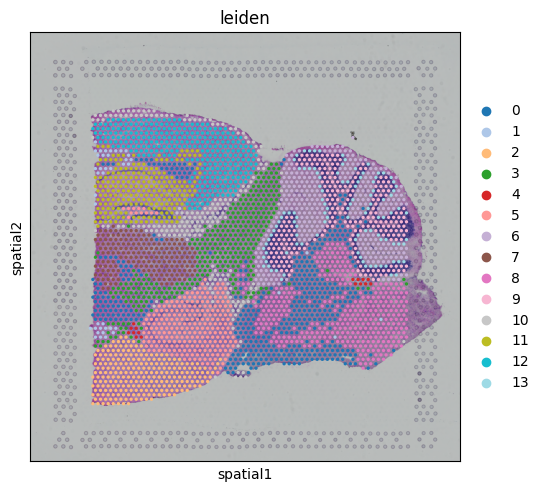

In [11]:
sq.pl.spatial_scatter(
    adata,
    color="leiden",
    palette="tab20"
)

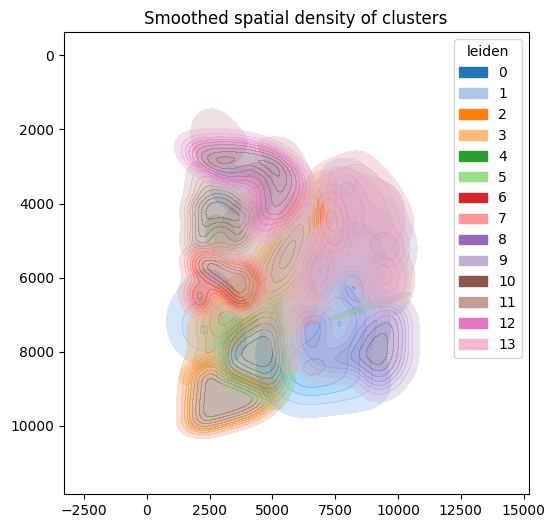

In [13]:
coords = adata.obsm["spatial"]
labels = adata.obs["leiden"]

plt.figure(figsize=(6,6))

sns.kdeplot(
    x=coords[:,0],
    y=coords[:,1],
    hue=labels,
    fill=True,
    alpha=0.4,
    palette="tab20"
)

plt.gca().invert_yaxis()
plt.title("Smoothed spatial density of clusters")
plt.show()

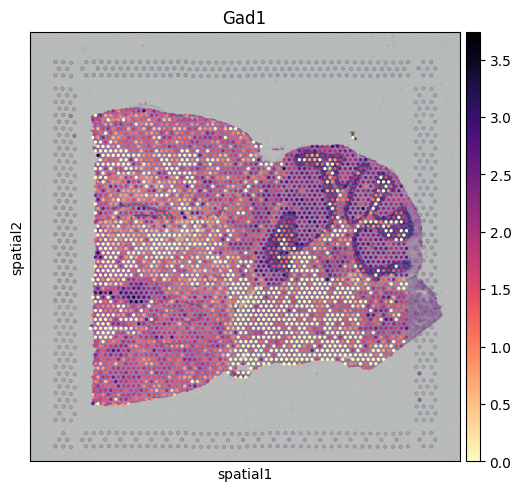

In [14]:
sq.pl.spatial_scatter(
    adata,
    color="Gad1",
    cmap="magma_r"
)

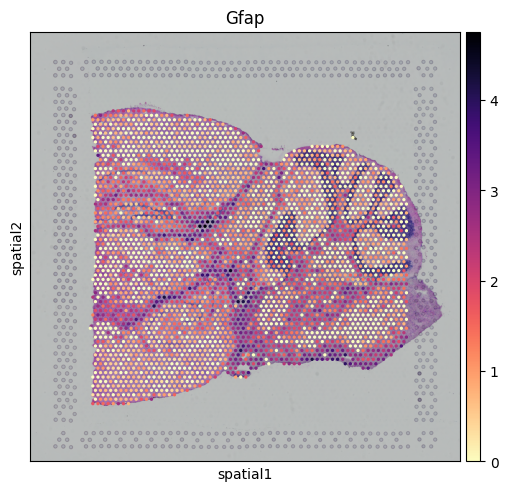

In [15]:
sq.pl.spatial_scatter(
    adata,
    color="Gfap",
    cmap="magma_r"
)

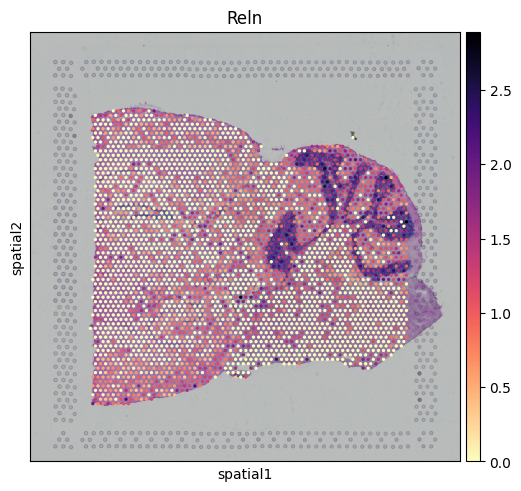

In [16]:
sq.pl.spatial_scatter(
    adata,
    color="Reln",
    cmap="magma_r"
)

'Allow threshold manipulation', 'Allow Gene Selection n change code', 'Size of graph', 'Resolution(Leiden Scale)',

In [19]:
def spatial_gene_regions(
    adata,
    gene="Reln",
    sigma=3,
    grid_size=300,
    cmap="magma",
    levels=(50, 75, 90),
    preserve_aspect=True
):
    coords = adata.obsm["spatial"]
    values = adata[:, gene].X

    # flatten expression
    if hasattr(values, "toarray"):
        values = values.toarray().flatten()
    else:
        values = np.array(values).flatten()

    x = coords[:, 0]
    y = coords[:, 1]

    # normalize coordinates to grid
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    x_norm = (x - x_min) / (x_max - x_min)
    y_norm = (y - y_min) / (y_max - y_min)

    xi = (x_norm * (grid_size - 1)).astype(int)
    yi = (y_norm * (grid_size - 1)).astype(int)

    # IMPORTANT: use [row=y, col=x]
    grid = np.zeros((grid_size, grid_size))

    for x_i, y_i, v in zip(xi, yi, values):
        grid[y_i, x_i] += v

    # smooth spatial signal
    smooth = gaussian_filter(grid, sigma=sigma)

    # percentile-based regioning (ignore zeros)
    nonzero = smooth[smooth > 0]
    thresholds = np.percentile(nonzero, levels)
    regions = np.digitize(smooth, thresholds)

    # plot
    plt.figure(figsize=(7, 6))

    img = plt.imshow(
        regions,
        origin="upper",
        cmap=cmap
    )

    plt.title(f"{gene.upper()} Spatial Expression Regions")
    plt.axis("off")

    plt.colorbar(img, label="Expression region level")

    # keep spatial proportions similar to original tissue
    if preserve_aspect:
        plt.gca().set_aspect("equal")

    plt.show()

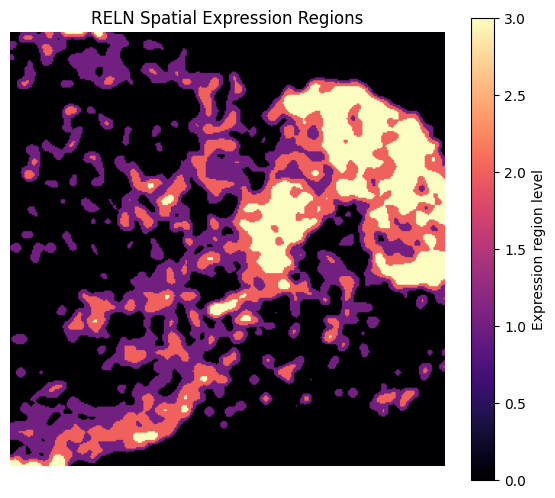

In [20]:
spatial_gene_regions(adata, gene="Reln")

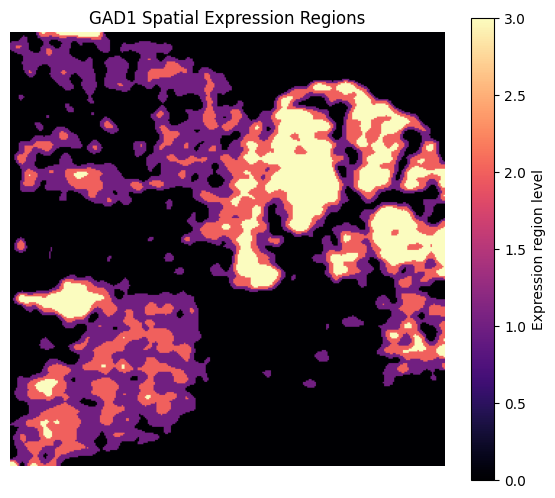

In [23]:
spatial_gene_regions(adata, gene="Gad1")

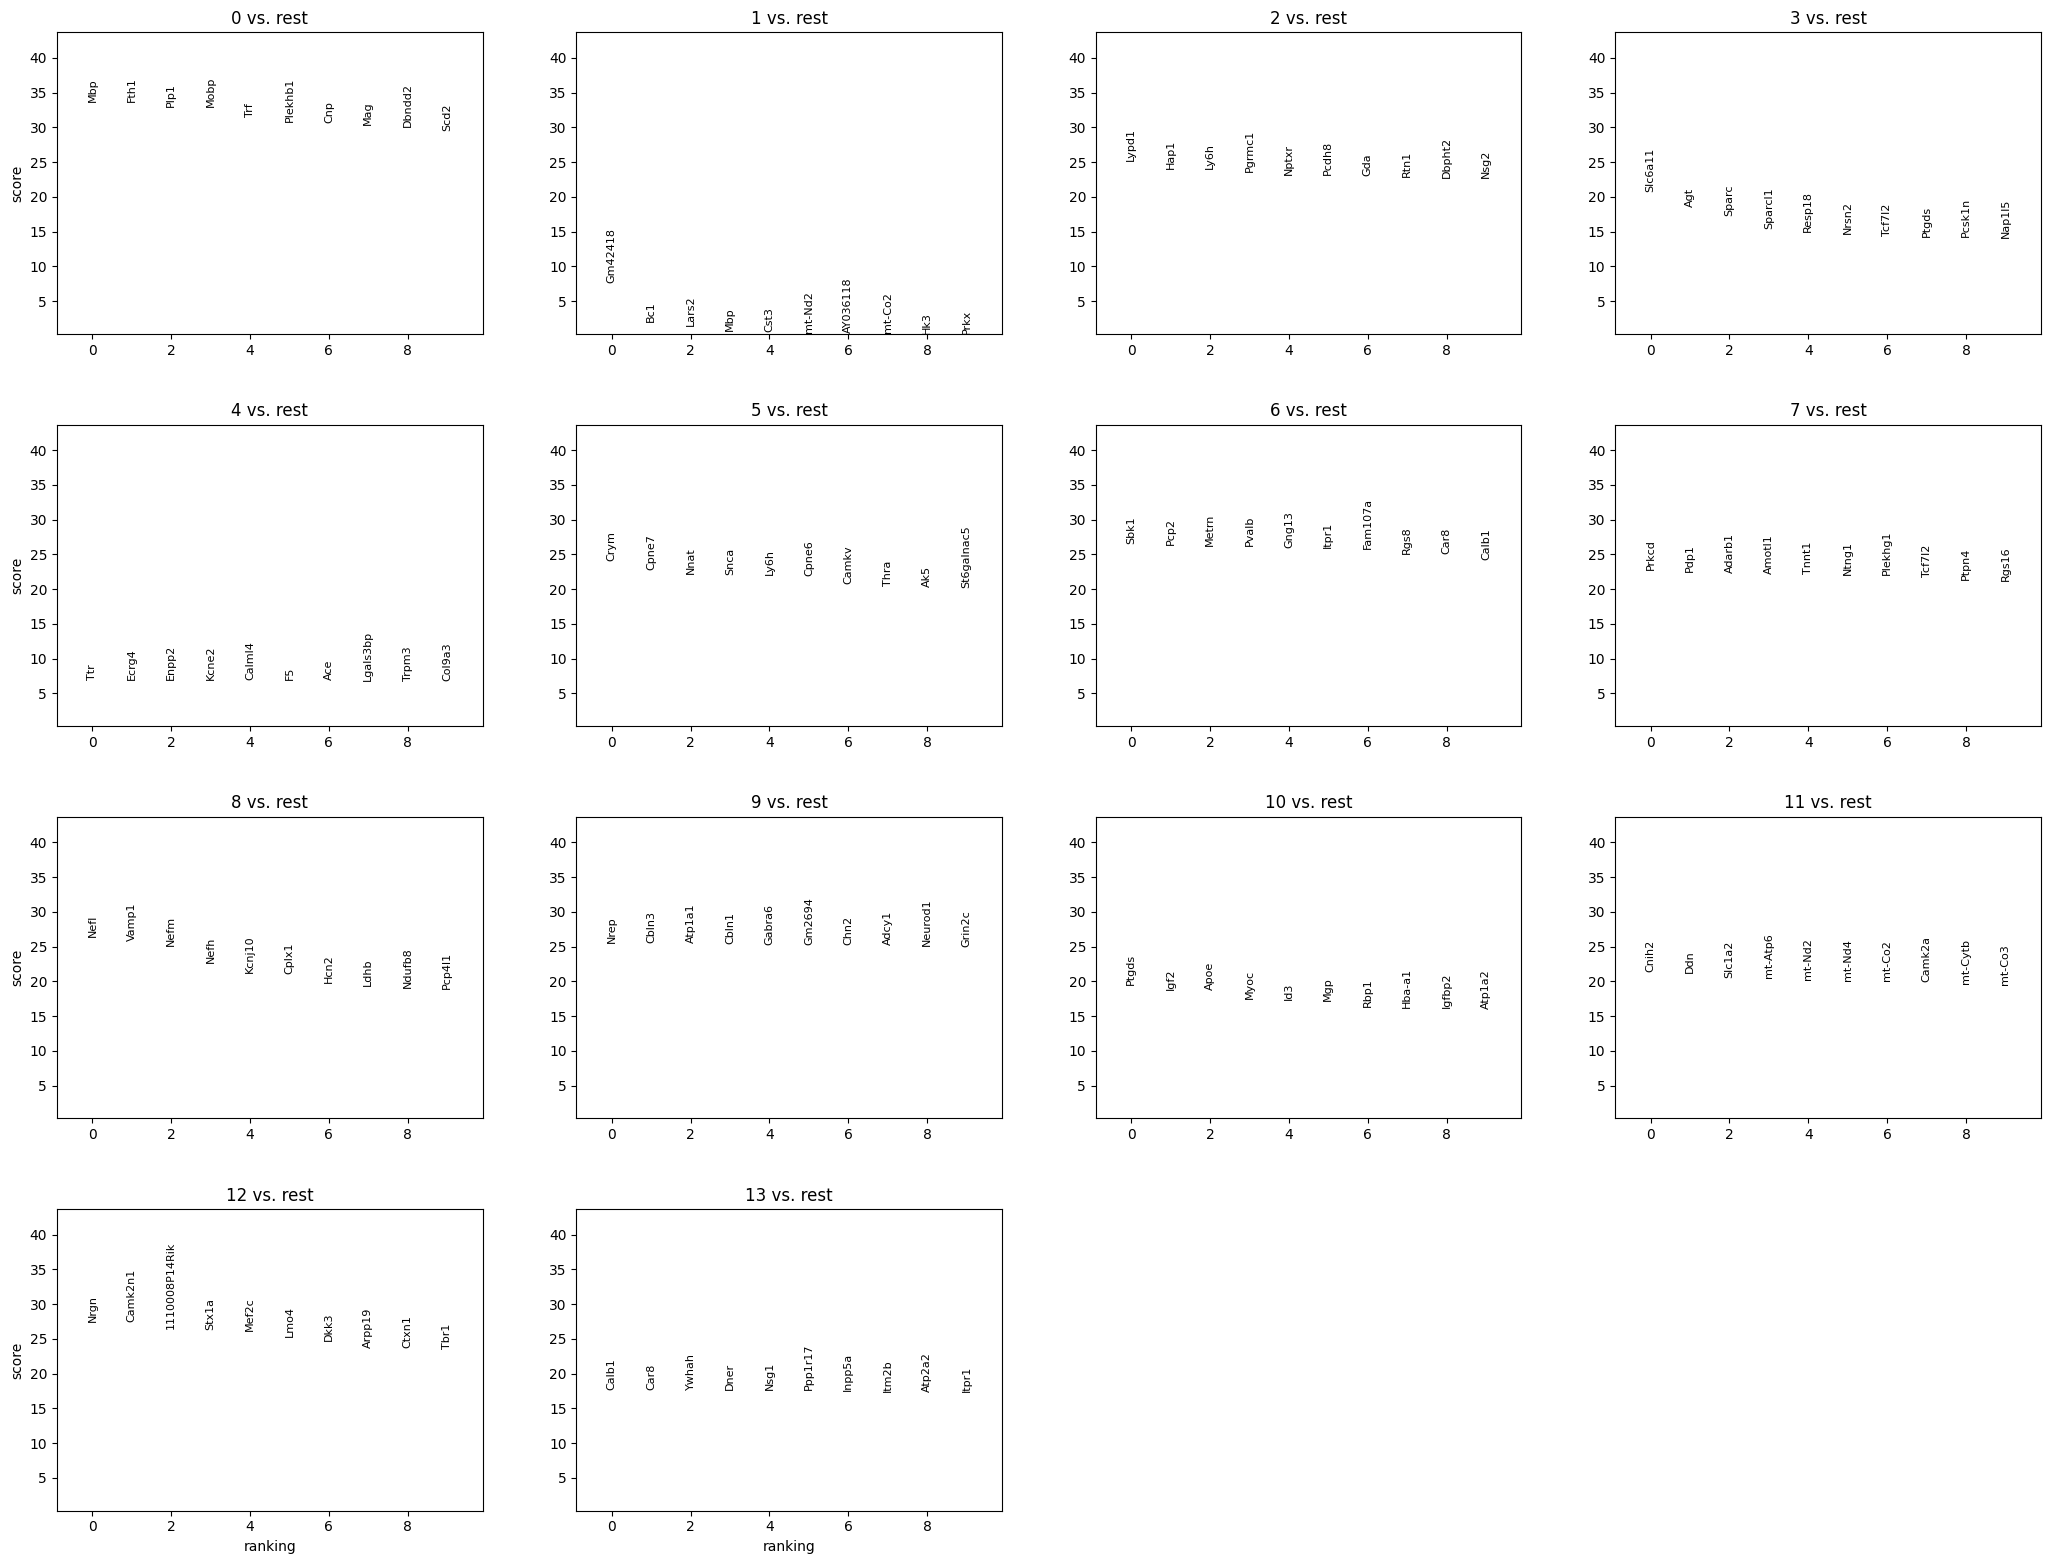

In [ ]:
adata.var_names_make_unique()

sc.tl.rank_genes_groups(
    adata,
    "leiden",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    adata,
    n_genes=10
)

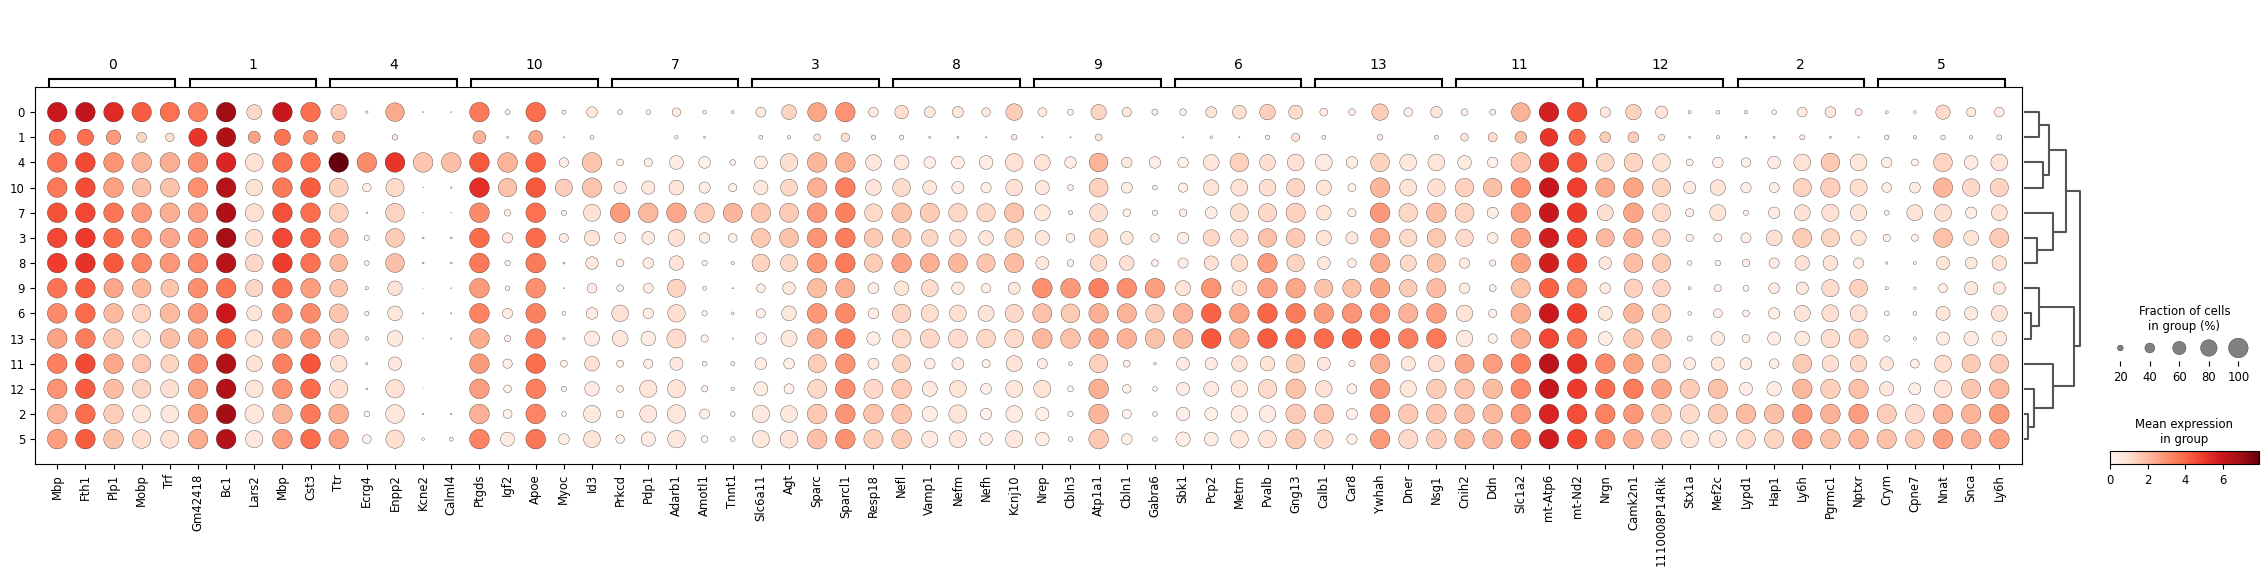

In [ ]:
adata.var_names_make_unique()
sc.tl.dendrogram(adata, groupby="leiden")

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5
)

In [ ]:
GENE = "Reln"
RESOLUTION = 0.5